# 1. Data Exploration

This notebook verifies the normalized dataset structure, inspects class balance, displays sample images, and reports the real image sizes/formats found in the local archive.

In [1]:
import os
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

DATA_DIR = Path('../data/animals_dataset')
TRAIN_DIR = DATA_DIR / 'train'
VAL_DIR = DATA_DIR / 'val'
TEST_DIR = DATA_DIR / 'test'
RESULTS_DIR = Path('../results')
RESULTS_DIR.mkdir(exist_ok=True)

IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png'}

assert DATA_DIR.exists(), f'Data not found at {DATA_DIR.resolve()}'
for split_dir in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    assert split_dir.exists(), f'Missing split directory: {split_dir}'

classes = sorted([item.name for item in TRAIN_DIR.iterdir() if item.is_dir()])
print(f'Found {len(classes)} classes: {classes}')


Found 5 classes: ['cat', 'cow', 'deer', 'dog', 'lion']


In [2]:
def image_files(folder: Path):
    return sorted([
        path for path in folder.iterdir()
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    ])

def count_images(split_dir: Path):
    counts = {}
    for class_name in sorted([item.name for item in split_dir.iterdir() if item.is_dir()]):
        counts[class_name] = len(image_files(split_dir / class_name))
    return counts

train_counts = count_images(TRAIN_DIR)
val_counts = count_images(VAL_DIR)
test_counts = count_images(TEST_DIR)

summary_df = pd.DataFrame([
    {'split': 'train', **train_counts},
    {'split': 'val', **val_counts},
    {'split': 'test', **test_counts},
]).set_index('split')

display(summary_df)
print('\nDataset totals:')
print(f"Train: {sum(train_counts.values())}")
print(f"Val:   {sum(val_counts.values())}")
print(f"Test:  {sum(test_counts.values())}")


,cat,cow,deer,dog,lion
split,,,,,
train,91,86,87,111,89
val,17,15,17,17,17
test,17,16,16,16,17



Dataset totals:
Train: 464
Val:   83
Test:  82


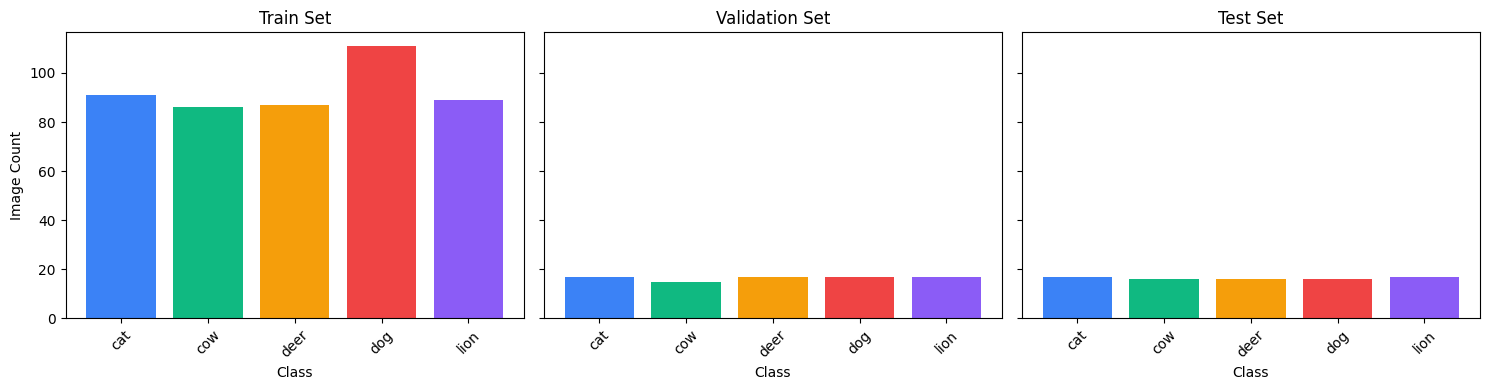

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for idx, (split_name, counts) in enumerate([
    ('Train', train_counts),
    ('Validation', val_counts),
    ('Test', test_counts),
]):
    axes[idx].bar(counts.keys(), counts.values(), color=['#3b82f6', '#10b981', '#f59e0b', '#ef4444', '#8b5cf6'])
    axes[idx].set_title(f'{split_name} Set')
    axes[idx].set_xlabel('Class')
    axes[idx].tick_params(axis='x', rotation=45)

axes[0].set_ylabel('Image Count')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


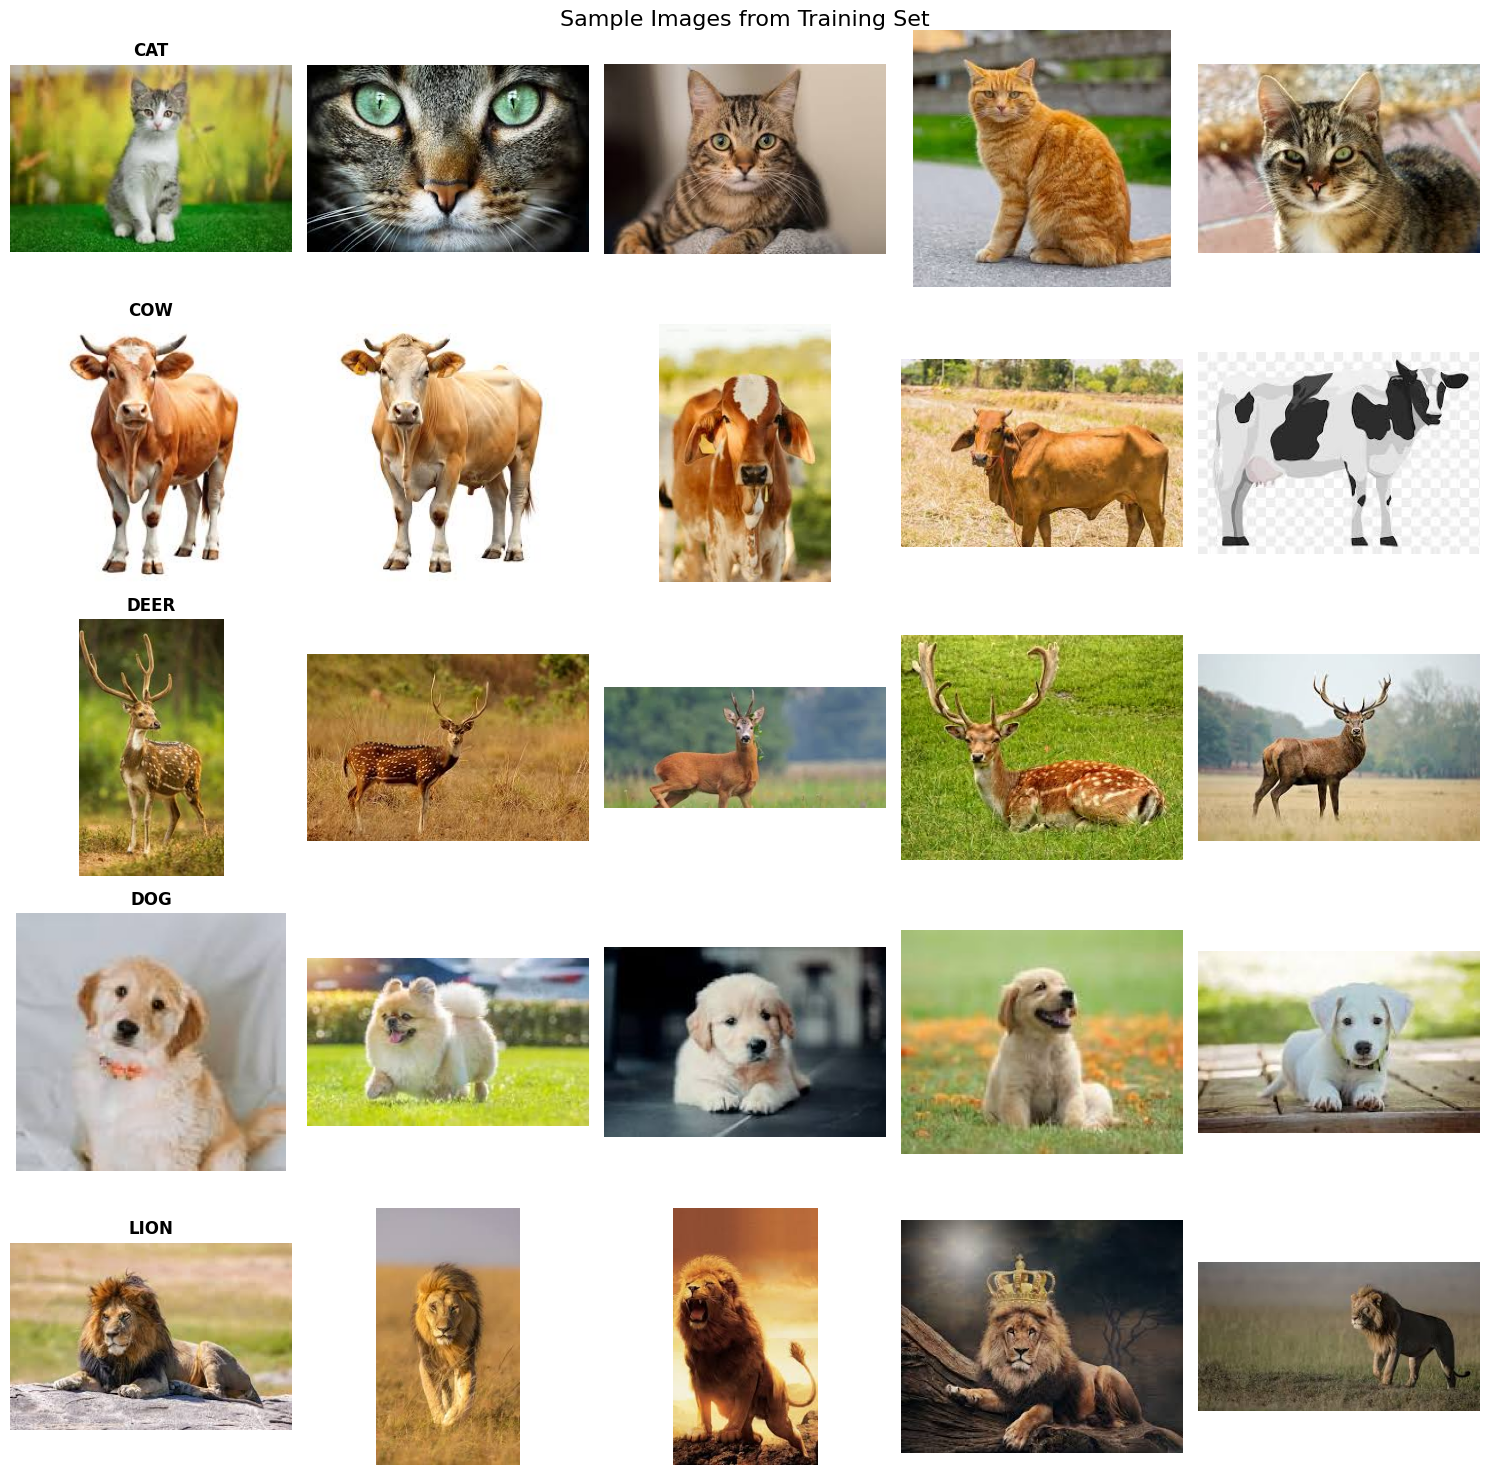

In [4]:
fig, axes = plt.subplots(len(classes), 5, figsize=(15, 3 * len(classes)))
fig.suptitle('Sample Images from Training Set', fontsize=16)

if len(classes) == 1:
    axes = [axes]

for i, class_name in enumerate(classes):
    samples = image_files(TRAIN_DIR / class_name)[:5]
    for j in range(5):
        ax = axes[i][j] if len(classes) > 1 else axes[j]
        ax.axis('off')
        if j < len(samples):
            with Image.open(samples[j]) as img:
                ax.imshow(img.convert('RGB'))
        if j == 0:
            ax.set_title(class_name.upper(), fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'sample_images.png', dpi=300, bbox_inches='tight')
plt.show()


In [5]:
size_counter = Counter()
format_counter = Counter()

for class_name in classes:
    for image_path in image_files(TRAIN_DIR / class_name)[:15]:
        with Image.open(image_path) as img:
            size_counter[img.size] += 1
            format_counter[img.format] += 1

print('Observed image sizes from training sample:')
for size, count in size_counter.most_common(10):
    print(f'  {size}: {count}')

print('\nObserved file formats from training sample:')
for file_format, count in format_counter.items():
    print(f'  {file_format}: {count}')

print('\nData exploration complete.')


Observed image sizes from training sample:
  (275, 183): 20
  (225, 225): 7
  (183, 275): 4
  (277, 182): 3
  (194, 259): 2
  (168, 299): 2
  (259, 194): 2
  (276, 183): 2
  (148, 148): 2
  (273, 184): 1

Observed file formats from training sample:
  JPEG: 75

Data exploration complete.
